<a href="https://colab.research.google.com/github/yedam823/TIL/blob/main/PID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gymnasium[classic_control]

In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

# 1. 신경망 구조 정의 (상태 4개 -> 행동 2개)
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2) # 왼쪽, 오른쪽 이동의 가치(Q-value)
        )

    def forward(self, x):
        return self.fc(x)

# 2. 하이퍼파라미터 설정
EPISODES = 600      # 총 학습 횟수
GAMMA = 0.995        # 미래 보상 할인율
EPSILON_START = 1.0 # 무작위 탐색 확률 시작
EPSILON_END = 0.01  # 무작위 탐색 확률 최소치
EPSILON_DECAY = 0.997
BATCH_SIZE = 64
MEMORY_SIZE = 10000

# 3. 학습 클래스
class Agent:
    def __init__(self):
        self.model = DQN()
        self.target_model = DQN() # 안정적인 학습을 위한 타겟망
        self.target_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START

    def get_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 1) # 무작위 행동
        state = torch.FloatTensor(state).unsqueeze(0)
        return self.model(state).argmax().item() # 최적의 행동 선택

    def train(self):
        if len(self.memory) < BATCH_SIZE: return

        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones)

        # 현재 Q값
        current_q = self.model(states).gather(1, actions)
        # 미래 최대 Q값
        next_q = self.target_model(next_states).max(1)[0].detach()
        target_q = rewards + (GAMMA * next_q * (1 - dones))

        loss = nn.MSELoss()(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# 4. 메인 학습 루프
# 4. 메인 학습 루프 (수정본)
env = gym.make('CartPole-v1')
agent = Agent()

for e in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 쓰러지면 벌점, 버티면 가점
        x, v, theta, omega = next_state
        reward = 1.0 - abs(theta) / 0.209  # 각도가 커질수록 보상 감소
        if terminated: reward = -20 # 실패 시 벌점 강화

        agent.memory.append((state, action, reward, next_state, done))
        agent.train()

        state = next_state
        score += 1

        if done:
            print(f"에피소드: {e+1}/{EPISODES}, 점수: {score}, 탐색률: {agent.epsilon:.2f}")
            break

    # [수정된 부분] agent 객체를 통해 모델에 접근해야 합니다.
    if e % 10 == 0:
        agent.target_model.load_state_dict(agent.model.state_dict())

    # 탐색률 감소
    agent.epsilon = max(EPSILON_END, agent.epsilon * EPSILON_DECAY)

print("학습 완료!")

에피소드: 1/600, 점수: 34, 탐색률: 1.00
에피소드: 2/600, 점수: 33, 탐색률: 1.00
에피소드: 3/600, 점수: 45, 탐색률: 0.99
에피소드: 4/600, 점수: 11, 탐색률: 0.99
에피소드: 5/600, 점수: 42, 탐색률: 0.99
에피소드: 6/600, 점수: 10, 탐색률: 0.99
에피소드: 7/600, 점수: 11, 탐색률: 0.98
에피소드: 8/600, 점수: 11, 탐색률: 0.98
에피소드: 9/600, 점수: 30, 탐색률: 0.98
에피소드: 10/600, 점수: 34, 탐색률: 0.97
에피소드: 11/600, 점수: 19, 탐색률: 0.97
에피소드: 12/600, 점수: 24, 탐색률: 0.97
에피소드: 13/600, 점수: 18, 탐색률: 0.96
에피소드: 14/600, 점수: 18, 탐색률: 0.96
에피소드: 15/600, 점수: 11, 탐색률: 0.96
에피소드: 16/600, 점수: 20, 탐색률: 0.96
에피소드: 17/600, 점수: 28, 탐색률: 0.95
에피소드: 18/600, 점수: 18, 탐색률: 0.95
에피소드: 19/600, 점수: 24, 탐색률: 0.95
에피소드: 20/600, 점수: 16, 탐색률: 0.94
에피소드: 21/600, 점수: 110, 탐색률: 0.94
에피소드: 22/600, 점수: 13, 탐색률: 0.94
에피소드: 23/600, 점수: 34, 탐색률: 0.94
에피소드: 24/600, 점수: 28, 탐색률: 0.93
에피소드: 25/600, 점수: 15, 탐색률: 0.93
에피소드: 26/600, 점수: 14, 탐색률: 0.93
에피소드: 27/600, 점수: 51, 탐색률: 0.92
에피소드: 28/600, 점수: 43, 탐색률: 0.92
에피소드: 29/600, 점수: 12, 탐색률: 0.92
에피소드: 30/600, 점수: 55, 탐색률: 0.92
에피소드: 31/600, 점수: 13, 탐색률: 0.91
에피소드: 32/600, 점수

에피소드: 50, 최근 50판 평균 점수: 29.8
에피소드: 100, 최근 50판 평균 점수: 45.9
에피소드: 150, 최근 50판 평균 점수: 60.3
에피소드: 200, 최근 50판 평균 점수: 45.8
에피소드: 250, 최근 50판 평균 점수: 74.7
에피소드: 300, 최근 50판 평균 점수: 60.8
에피소드: 350, 최근 50판 평균 점수: 50.0
에피소드: 400, 최근 50판 평균 점수: 89.7
에피소드: 450, 최근 50판 평균 점수: 89.8
에피소드: 500, 최근 50판 평균 점수: 134.9
에피소드: 550, 최근 50판 평균 점수: 150.5
에피소드: 600, 최근 50판 평균 점수: 118.1


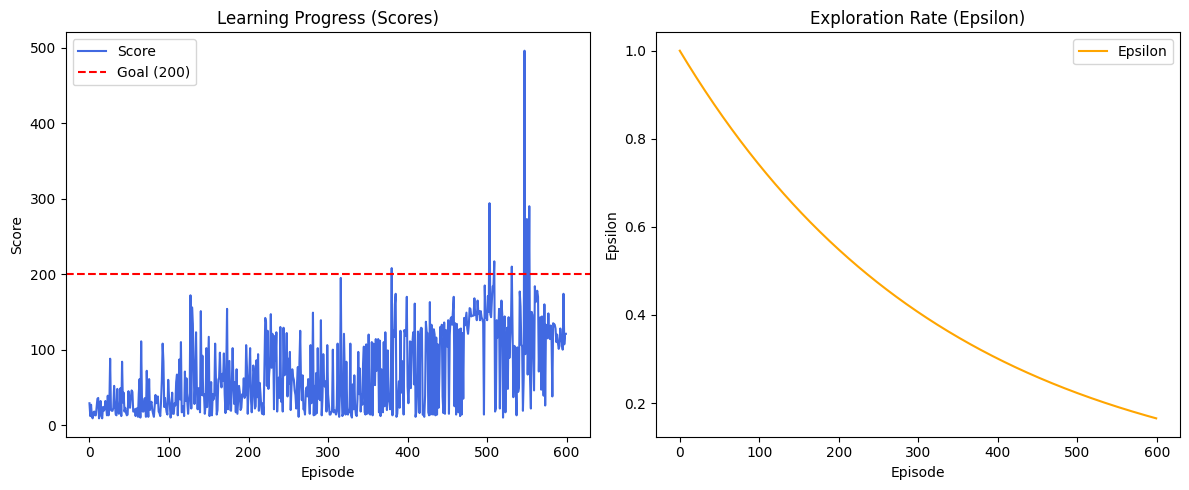

In [4]:
import matplotlib.pyplot as plt

# 점수 저장을 위한 리스트
score_history = []
epsilon_history = []

# 메인 학습 루프 (기존 루프에 기록 기능 추가)
env = gym.make('CartPole-v1')
agent = Agent()

for e in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 보상 조정
        reward = reward if not terminated else -10
        agent.memory.append((state, action, reward, next_state, done))
        agent.train()

        state = next_state
        score += 1

        if done:
            score_history.append(score) # 점수 기록
            epsilon_history.append(agent.epsilon) # 탐색률 기록
            if (e + 1) % 50 == 0:
                print(f"에피소드: {e+1}, 최근 50판 평균 점수: {np.mean(score_history[-10:]):.1f}")
            break

    if e % 10 == 0:
        agent.target_model.load_state_dict(agent.model.state_dict())
    agent.epsilon = max(EPSILON_END, agent.epsilon * EPSILON_DECAY)

# --- 그래프 그리기 ---
plt.figure(figsize=(12, 5))

# 1. 점수 그래프
plt.subplot(1, 2, 1)
plt.plot(score_history, color='royalblue', label='Score')
plt.axhline(y=200, color='r', linestyle='--', label='Goal (200)')
plt.title('Learning Progress (Scores)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()

# 2. 탐색률(Epsilon) 그래프
plt.subplot(1, 2, 2)
plt.plot(epsilon_history, color='orange', label='Epsilon')
plt.title('Exploration Rate (Epsilon)')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.legend()

plt.tight_layout()
plt.show()